# Emotion Classification Model

Utilizing transfer learning on a Audio Spectrogram Transformer model, the goal is to be able to accurately classify any emotion in our data set.

Hugging Face Model:
MIT/ast-finetuned-audioset-10-10-0.4593

# Model Configuration
Drop out layers and Early Stopping were added to the model in order to prevent the model from overfitting and memorizing data during training

In [2]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 65.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [45]:
# Audio Classification Model
#Trained Hugging face Model: ast-finetuned-audioset-10-10-0.4593.ipynb

from transformers import pipeline
pipe = pipeline("audio-classification", model="MIT/ast-finetuned-audioset-10-10-0.4593")

# Load model directly
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, ASTForAudioClassification, Trainer,TrainingArguments, Trainer, EarlyStoppingCallback

extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
model = AutoModelForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

In [4]:
# Data
from google.colab import drive
import os
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
from torch.utils.data import Dataset
from collections import Counter
import matplotlib.pyplot as plt

drive.mount('/content/gdrive')
emotion_data = "/content/gdrive/MyDrive/ds340-project-data/Data/clean-pain-only/npy/all-emotions"

Mounted at /content/gdrive


In [5]:
# Data Setup for multi-class emotion classification

# Emotion code -> label
emotion_map = {
    "01": "boredom",
    "02": "neutral",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
    "09": "excited",
    "10": "pleasure",
    "11": "pain",
    "12": "disappointment",
    "13": "breath"
}

# Label -> integer id
label2id = {label: i for i, label in enumerate(emotion_map.values())}
id2label = {i: label for label, i in label2id.items()}

def get_emotion_label_from_filename(filename):
    """
    Example filename:
    03-01-06-01-02-12-02-01-01-16.npy

    Emotion is the 3rd field -> index 2
    """
    stem = Path(filename).stem
    parts = stem.split("-")

    if len(parts) < 3:
        raise ValueError(f"Bad filename format: {filename}")

    emotion_code = parts[2]

    if emotion_code not in emotion_map:
        raise ValueError(f"Unknown emotion code {emotion_code} in {filename}")

    return emotion_map[emotion_code]

# Collect all .npy files
all_files = []
all_labels = []

for f in os.listdir(emotion_data):
    if f.endswith(".npy"):
        full_path = os.path.join(emotion_data, f)
        emotion_label = get_emotion_label_from_filename(f)

        all_files.append(full_path)
        all_labels.append(label2id[emotion_label])

print("Total files:", len(all_files))

# Show counts for each emotion
label_names = [id2label[label_id] for label_id in all_labels]
counts = Counter(label_names)

print("\nClass counts:")
for emotion, count in sorted(counts.items()):
    print(f"{emotion}: {count}")

# Quick shape check
if len(all_files) > 0:
    sample = np.load(all_files[0])
    print("\nSample shape:", sample.shape)

# MODEL
model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
)

# Train / validation split
train_files, val_files, train_labels, val_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)

print("\nTraining samples:", len(train_files))
print("Validation samples:", len(val_files))
print("\nlabel2id:", label2id)
print("id2label:", id2label)

Total files: 2101

Class counts:
happy: 869
neutral: 246
pain: 715
pleasure: 271

Sample shape: (128, 94)


[transformers] You passed `num_labels=13` which is incompatible to the `id2label` map of length `527`.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([13, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([13])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



Training samples: 1680
Validation samples: 421

label2id: {'boredom': 0, 'neutral': 1, 'happy': 2, 'sad': 3, 'angry': 4, 'fearful': 5, 'disgust': 6, 'surprised': 7, 'excited': 8, 'pleasure': 9, 'pain': 10, 'disappointment': 11, 'breath': 12}
id2label: {0: 'boredom', 1: 'neutral', 2: 'happy', 3: 'sad', 4: 'angry', 5: 'fearful', 6: 'disgust', 7: 'surprised', 8: 'excited', 9: 'pleasure', 10: 'pain', 11: 'disappointment', 12: 'breath'}


In [6]:
# DATASET

TARGET_LENGTH = model.config.max_length
NUM_MEL_BINS = model.config.num_mel_bins

print("TARGET_LENGTH:", TARGET_LENGTH)
print("NUM_MEL_BINS:", NUM_MEL_BINS)

# Clean Data
"""
I added this because a file was giving me issues that crashed
the model during training.

"""
def is_valid_npy_file(file_path, num_mel_bins):
    try:
        spec = np.load(file_path).astype(np.float32)

        if spec.ndim != 2:
            return False

        # allow either (time, mel) or (mel, time)
        if spec.shape[1] == num_mel_bins:
            return True
        if spec.shape[0] == num_mel_bins:
            return True

        return False
    except Exception:
        return False

def filter_valid_files(file_paths, labels, num_mel_bins):
    good_files = []
    good_labels = []
    bad_files = []

    for file_path, label in zip(file_paths, labels):
        if is_valid_npy_file(file_path, num_mel_bins):
            good_files.append(file_path)
            good_labels.append(label)
        else:
            bad_files.append(file_path)

    return good_files, good_labels, bad_files

all_files, all_labels, bad_files = filter_valid_files(all_files, all_labels, NUM_MEL_BINS)

print("Valid files:", len(all_files))
print("Bad files removed:", len(bad_files))

if len(bad_files) > 0:
    print("Some bad files:")
    for f in bad_files[:20]:
        print(f)

# re-split after filtering
train_files, val_files, train_labels, val_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)


class EmotionSpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels, target_length, num_mel_bins):
        self.file_paths = file_paths
        self.labels = labels
        self.target_length = target_length
        self.num_mel_bins = num_mel_bins

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]

        try:
            spec = np.load(file_path).astype(np.float32)
        except Exception as e:
            raise ValueError(f"Could not load file {file_path}: {e}")

        if spec.ndim != 2:
            raise ValueError(f"Expected 2D spectrogram, got shape {spec.shape} for {file_path}")

        if spec.shape[0] == self.num_mel_bins and spec.shape[1] != self.num_mel_bins:
            spec = spec.T

        if spec.shape[1] != self.num_mel_bins:
            raise ValueError(
                f"Expected spectrogram with {self.num_mel_bins} mel bins, got shape {spec.shape} for {file_path}"
            )

        time_steps = spec.shape[0]

        if time_steps > self.target_length:
            spec = spec[:self.target_length, :]
        elif time_steps < self.target_length:
            pad_amount = self.target_length - time_steps
            spec = np.pad(spec, ((0, pad_amount), (0, 0)), mode="constant")

        mean = spec.mean()
        std = spec.std() + 1e-6
        spec = (spec - mean) / std

        return {
            "input_values": torch.tensor(spec, dtype=torch.float32),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = EmotionSpectrogramDataset(
    train_files,
    train_labels,
    target_length=TARGET_LENGTH,
    num_mel_bins=NUM_MEL_BINS
)

val_dataset = EmotionSpectrogramDataset(
    val_files,
    val_labels,
    target_length=TARGET_LENGTH,
    num_mel_bins=NUM_MEL_BINS
)


# METRICS

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# TRAINING ARGUMENTS

training_args = TrainingArguments(
    output_dir="./ast_emotion_multiclass",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=100,
    learning_rate=2e-6,
    weight_decay=1e-3,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    remove_unused_columns=False
)


# 9. CALLBACK TO LOG TRAIN METRICS EACH EPOCH

class TrainSetMetricsCallback(TrainerCallback):
    def __init__(self):
        self.trainer = None
        self._running = False

    def on_evaluate(self, args, state, control, **kwargs):
        if self.trainer is None or self._running:
            return

        self._running = True
        self.trainer.evaluate(
            eval_dataset=self.trainer.train_dataset,
            metric_key_prefix="train"
        )
        self._running = False

train_metrics_callback = TrainSetMetricsCallback()


# TRAINER

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        train_metrics_callback
    ]
)

train_metrics_callback.trainer = trainer


#  TRAIN / SAVE

train_output = trainer.train()

print("Training finished.")
print("Train metrics:", train_output.metrics)

val_logs = [entry for entry in trainer.state.log_history if "eval_loss" in entry]
train_logs = [entry for entry in trainer.state.log_history if "train_loss" in entry and "train_accuracy" in entry]

if len(val_logs) > 0:
    print("Final validation metrics:", val_logs[-1])
else:
    print("No validation metrics were found in log_history.")

if len(train_logs) > 0:
    print("Final training-set metrics:", train_logs[-1])
else:
    print("No training-set metrics were found in log_history.")

trainer.save_model("./ast_emotion_multiclass_best")

TARGET_LENGTH: 1024
NUM_MEL_BINS: 128
Valid files: 2100
Bad files removed: 1
Some bad files:
/content/gdrive/MyDrive/ds340-project-data/Data/clean-pain-only/npy/all-emotions/03-02-11-01-01-72-02-02-02-11 - Copy.npy


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.532015,1.288745,0.509524,0.561084,0.509524,0.525508
2,1.229840,1.110222,0.552381,0.555461,0.552381,0.539076
3,1.087845,1.072222,0.545238,0.515129,0.545238,0.500127
4,0.961908,1.273494,0.535714,0.539416,0.535714,0.472990


[transformers] early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished.
Train metrics: {'train_runtime': 2814.2027, 'train_samples_per_second': 59.697, 'train_steps_per_second': 7.462, 'total_flos': 4.555453884058829e+17, 'train_loss': 1.2029017493838357, 'epoch': 4.0}
Final validation metrics: {'eval_loss': 1.2734943628311157, 'eval_accuracy': 0.5357142857142857, 'eval_precision': 0.5394160905017797, 'eval_recall': 0.5357142857142857, 'eval_f1': 0.47299044600077567, 'eval_runtime': 36.8458, 'eval_samples_per_second': 11.399, 'eval_steps_per_second': 1.438, 'epoch': 4.0, 'step': 840}
Final training-set metrics: {'train_loss': 1.2746050357818604, 'train_accuracy': 0.5279761904761905, 'train_precision': 0.5434041612288829, 'train_recall': 0.5279761904761905, 'train_f1': 0.4638231132263953, 'train_runtime': 147.4205, 'train_samples_per_second': 11.396, 'train_steps_per_second': 1.424, 'epoch': 4.0, 'step': 840}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [39]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_epochs = []
train_loss = []
train_accuracy = []
train_precision = []
train_recall = []
train_f1 = []

eval_epochs = []
eval_loss = []
eval_accuracy = []
eval_precision = []
eval_recall = []
eval_f1 = []

for entry in log_history:
    if "train_loss" in entry and "train_accuracy" in entry and "epoch" in entry:
        train_epochs.append(entry["epoch"])
        train_loss.append(entry.get("train_loss"))
        train_accuracy.append(entry.get("train_accuracy"))
        train_precision.append(entry.get("train_precision"))
        train_recall.append(entry.get("train_recall"))
        train_f1.append(entry.get("train_f1"))

    if "eval_loss" in entry and "epoch" in entry:
        eval_epochs.append(entry["epoch"])
        eval_loss.append(entry.get("eval_loss"))
        eval_accuracy.append(entry.get("eval_accuracy"))
        eval_precision.append(entry.get("eval_precision"))
        eval_recall.append(entry.get("eval_recall"))
        eval_f1.append(entry.get("eval_f1"))

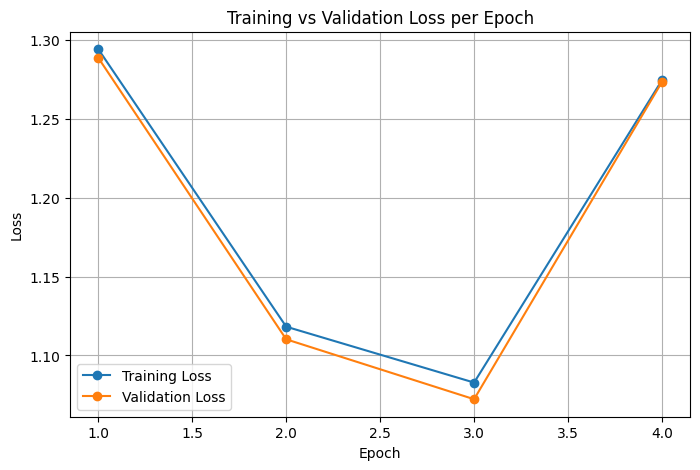

In [40]:
# 1. Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
plt.plot(eval_epochs, eval_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

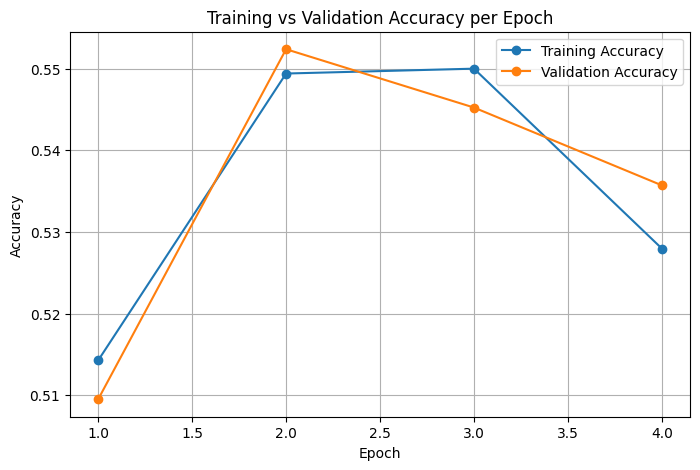

In [41]:
# 2. Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_accuracy, marker="o", label="Training Accuracy")
plt.plot(eval_epochs, eval_accuracy, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

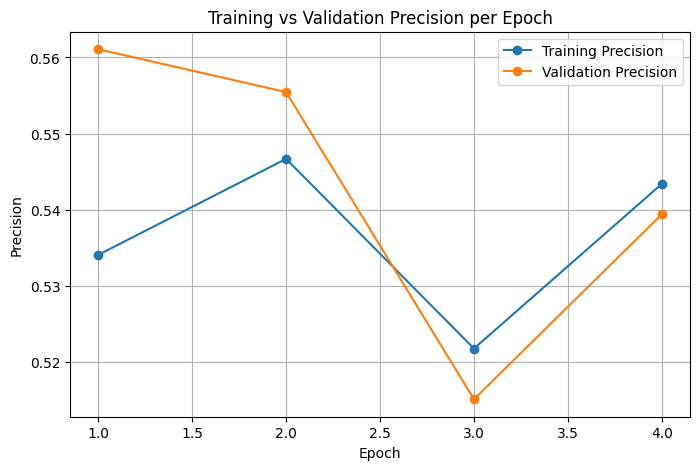

In [42]:
# 3. Training vs Validation Precision
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_precision, marker="o", label="Training Precision")
plt.plot(eval_epochs, eval_precision, marker="o", label="Validation Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training vs Validation Precision per Epoch")
plt.legend()
plt.grid(True)
plt.show()

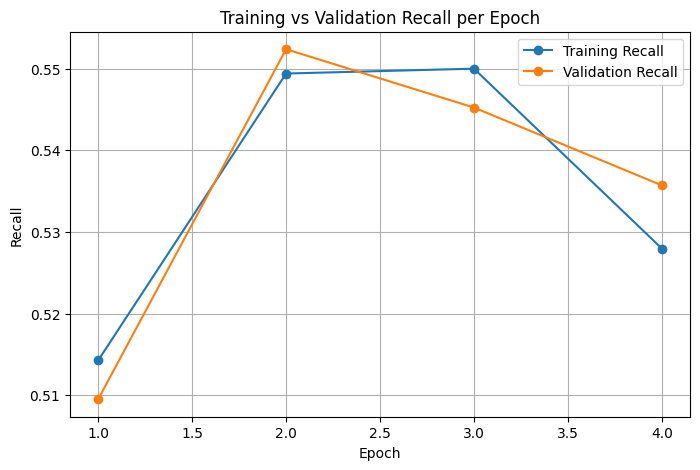

In [43]:
# 4. Training vs Validation Recall
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_recall, marker="o", label="Training Recall")
plt.plot(eval_epochs, eval_recall, marker="o", label="Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall per Epoch")
plt.legend()
plt.grid(True)
plt.show()

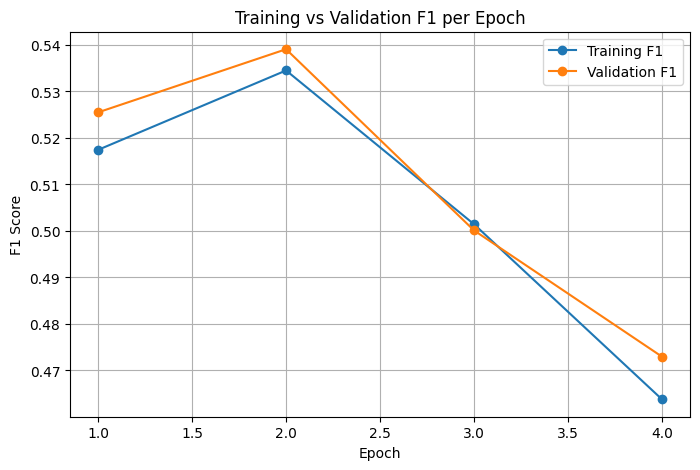

In [44]:
# 5. Training vs Validation F1
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_f1, marker="o", label="Training F1")
plt.plot(eval_epochs, eval_f1, marker="o", label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Training vs Validation F1 per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# SINGLE SPECTROGRAM INFERENCE FOR MULTICLASS EMOTION MODEL
import torch
import numpy as np
import matplotlib.pyplot as plt

def predict_single_emotion_spectrogram(file_path, model, target_length, num_mel_bins):
    model.eval()

    device = next(model.parameters()).device

    spec = np.load(file_path).astype(np.float32)
    original_shape = spec.shape

    print("Original shape:", original_shape)

    if spec.ndim != 2:
        raise ValueError(f"Expected 2D spectrogram, got shape {spec.shape} for {file_path}")

    if spec.shape[0] == num_mel_bins and spec.shape[1] != num_mel_bins:
        spec = spec.T

    if spec.shape[1] != num_mel_bins:
        raise ValueError(
            f"Expected spectrogram with {num_mel_bins} mel bins, got shape {spec.shape} for {file_path}"
        )

    # Show the unpadded/uncropped spectrogram currently being judged
    display_spec = spec.copy()

    plt.figure(figsize=(10, 4))
    plt.imshow(display_spec.T, aspect="auto", origin="lower")
    plt.xlabel("Time")
    plt.ylabel("Mel Bin")
    plt.title("Original Spectrogram Being Judged")
    plt.colorbar()
    plt.show()

    # Crop or pad time dimension
    time_steps = spec.shape[0]

    if time_steps > target_length:
        spec = spec[:target_length, :]
    elif time_steps < target_length:
        pad_amount = target_length - time_steps
        spec = np.pad(spec, ((0, pad_amount), (0, 0)), mode="constant")

    # Normalize
    mean = spec.mean()
    std = spec.std() + 1e-6
    spec = (spec - mean) / std

    processed_shape = spec.shape

    # Add batch dimension and move to same device as model
    input_tensor = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_values=input_tensor)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    prediction = model.config.id2label[pred_idx]

    print("Processed shape:", processed_shape)
    print("Prediction:", prediction)
    print("Threshold: N/A for multiclass argmax prediction")
    print("\nClass probabilities:")

    sorted_probs = sorted(
        [(model.config.id2label[i], float(probs[i])) for i in range(len(probs))],
        key=lambda x: x[1],
        reverse=True
    )

    for label, prob in sorted_probs:
        print(f"{label}: {prob:.6f}")

    # Horizontal bar chart of class probabilities
    class_names = [label for label, prob in sorted_probs]
    class_probs = [prob for label, prob in sorted_probs]

    plt.figure(figsize=(12, 6))
    plt.barh(class_names, class_probs)
    plt.xlabel("Probability")
    plt.ylabel("Emotion")
    plt.title("Class Probabilities")
    plt.xlim(0, 1)
    plt.gca().invert_yaxis()
    plt.show()

    return {
        "original_shape": tuple(original_shape),
        "processed_shape": tuple(processed_shape),
        "prediction": prediction,
        "probabilities": {label: prob for label, prob in sorted_probs},
        "threshold": "N/A for multiclass argmax prediction"
    }

Original shape: (128, 94)


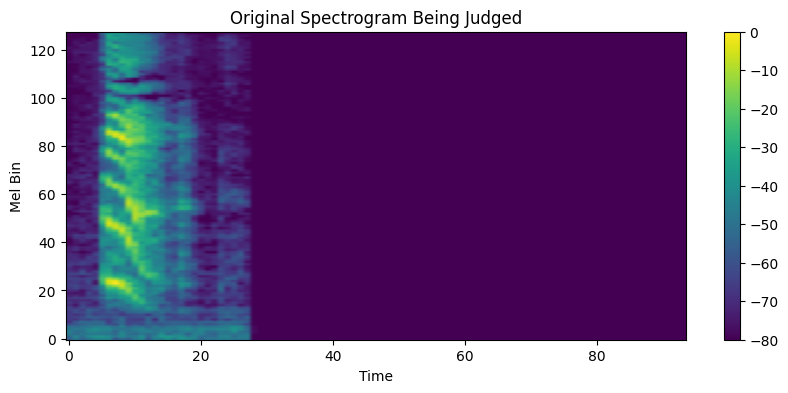

Processed shape: (1024, 128)
Prediction: pleasure
Threshold: N/A for multiclass argmax prediction

Class probabilities:
pleasure: 0.440894
neutral: 0.190630
happy: 0.159516
pain: 0.144270
sad: 0.011727
excited: 0.010069
disappointment: 0.007792
breath: 0.007738
fearful: 0.007117
surprised: 0.005394
disgust: 0.005261
boredom: 0.005156
angry: 0.004436


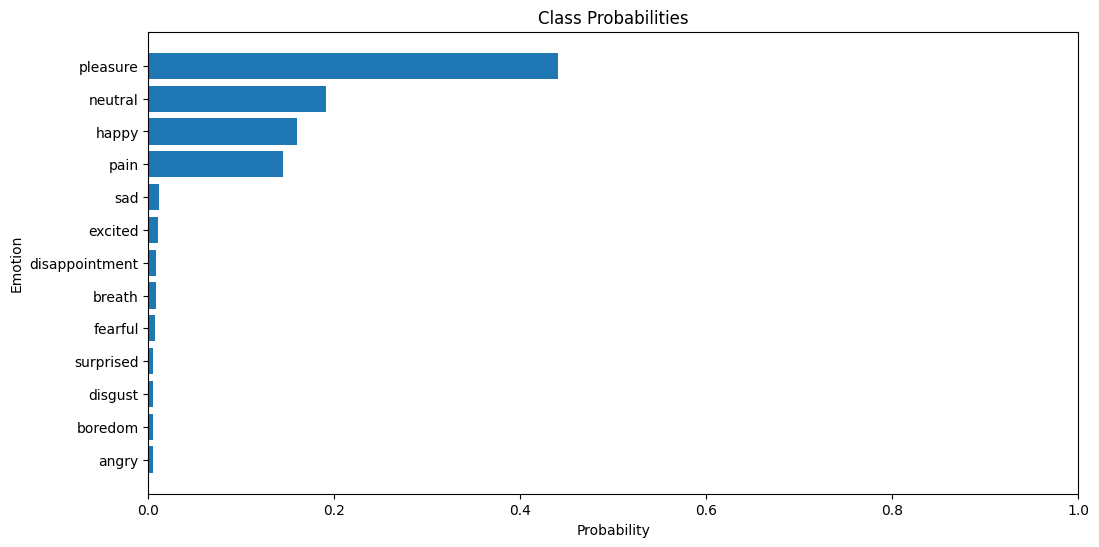

In [38]:
sample_file = val_files[0]
result = predict_single_emotion_spectrogram(
    file_path=sample_file,
    model=model,
    target_length=TARGET_LENGTH,
    num_mel_bins=NUM_MEL_BINS
)